# tacvar_visual
## tacvar_visual.draw_heatmap_npb_mpi：对指定测试结果的 region_id / loc_id 绘制多测点热力图

对指定测试结果的 `region_id` 与 `loc_id` 数据绘制多个测点的热力图：横轴为测点序号（按 CSV 行序），纵轴为 MPI 进程号（`rank`），色块为离散分箱颜色（深绿–浅绿–白–浅红–深红）。每个实际存在的 `(region_id, loc_id)` 单独一张图。图高固定为 1024 像素；标题与轴标注使用学术印刷风格（Cambria / serif）。

请在 `scripts/` 目录下打开本 notebook，以便 `import tacvar_visual` 可用。CSV 路径形如：

```text
<data_root>/<kernel_name>.<kernel_class>/<short_host>_rRRRR_tTTTT_pPID.csv
```

### 函数原型

```python
tacvar_visual.draw_heatmap_npb_mpi(
    data_root='', kernel_name='', kernel_class='',
    hosts=['all'], region_ids=range(0), loc_ids=range(0),
    fom='elapsed_ns', xrange=-1, ref_section_base=True,
    ref_key='median', ref_base='all',
    bars=[-15, -5, -1, 1, 5, 15],
)
```

`hosts` / `region_ids` / `loc_ids` 及之后的参数为 **keyword-only**。修改模块后请 `importlib.reload` 或重启 kernel。

### 参数说明

| 参数 | 含义 |
|------|------|
| `data_root` / `kernel_name` / `kernel_class` | 定位 `{data_root}/{kernel_name}.{kernel_class}/` |
| `hosts` | `['all']` / `['']` / 空 → 全部主机；否则按 CSV 文件名中的 `short_host` 过滤 |
| `region_ids` | 要绘制的 `region_id`；空可迭代对象（如 `range(0)`）→ 全部 region |
| `loc_ids` | 要绘制的 `loc_id`；空 → 全部 loc；仅绘制数据中实际存在的 (region, loc) 对 |
| `fom` | 数值列名，默认 `elapsed_ns` |
| `xrange` | 要绘制的测点列：`-1` 为全部；`list` 为指定下标；`tuple (a, b)` 为整数切片 `[a, b)`，或两端为 `[0, 1]` 内浮点时取 `[int(n*a), int(n*b))`。整数 `(0, 1)` 只含列 0 |
| `ref_section_base` | `True`：按 `xrange` 窗口计算参考值；`False`：按全部测点计算（图仍只画 `xrange`）。`xrange=-1` 时二者相同 |
| `ref_key` | 参考值统计量：`max` / `min` / `median` / `average`（`mean` 同义）/ `pxx`（百分位，如 `p50`、`p90`） |
| `ref_base` | 参考值样本集合：`all`（全局一个 ref）；`x`（该 seq 的全部 rank）；`y`（该 rank 的 seq，范围受 `ref_section_base` 约束） |
| `bars` | 相对参考的**百分比偏差**切点，须严格递增；分箱数为 `len(bars)+1` |

标题格式：

```text
{fom} heatmap of {Kernel.Class} on {host} (region={region_name}, loc_id={id})
```

色值语义：对每个样本计算 `value / ref`，再落入离散分箱。相对 `ref` 更负 → 更深的绿；包含比值 `1.0`（0% 偏差）的箱 → **始终为白**；更正 → 更深的红。将 `bars` 中的百分比 `p` 转为比值边 `1+p/100`，再补上两端无穷。例如 `bars=[a,b,c]`：

1. `(-inf, a]`
2. `(a, b]`
3. `(b, c]`
4. `(c, +inf)`

默认 `bars=[-15, -5, -1, 1, 5, 15]` 共 7 箱，白箱为 `(-1%, 1%]`。


timer_info for cg.C (/mnt/keylabmain/nfs/hpckey/03-Project/TacVar_NPC/suites/NPB3.4.4/NPB3.4-MPI/data_20260813T092308/cg.C)
 region_id  nloc  name
         1     1 total
         2     1 conjg
         3     8 rcomm
         4     2 ncomm
region_id=3 (rcomm), loc_id=1: 128 ranks, 8 data points of 76
region_id=3 (rcomm), loc_id=2: 128 ranks, 190 data points of 1900
region_id=3 (rcomm), loc_id=3: 128 ranks, 190 data points of 1900
region_id=3 (rcomm), loc_id=4: 128 ranks, 190 data points of 1900
region_id=3 (rcomm), loc_id=5: 128 ranks, 190 data points of 1900
region_id=3 (rcomm), loc_id=6: 128 ranks, 8 data points of 76
region_id=3 (rcomm), loc_id=7: 128 ranks, 8 data points of 76
region_id=3 (rcomm), loc_id=8: 128 ranks, 8 data points of 76


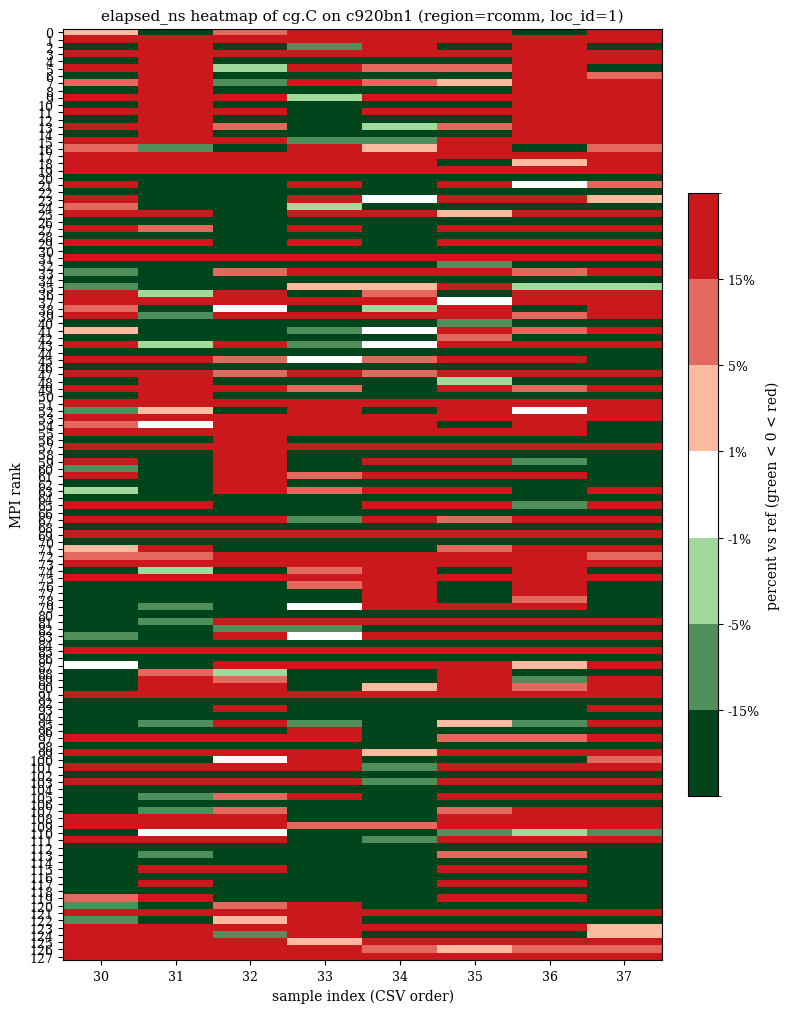

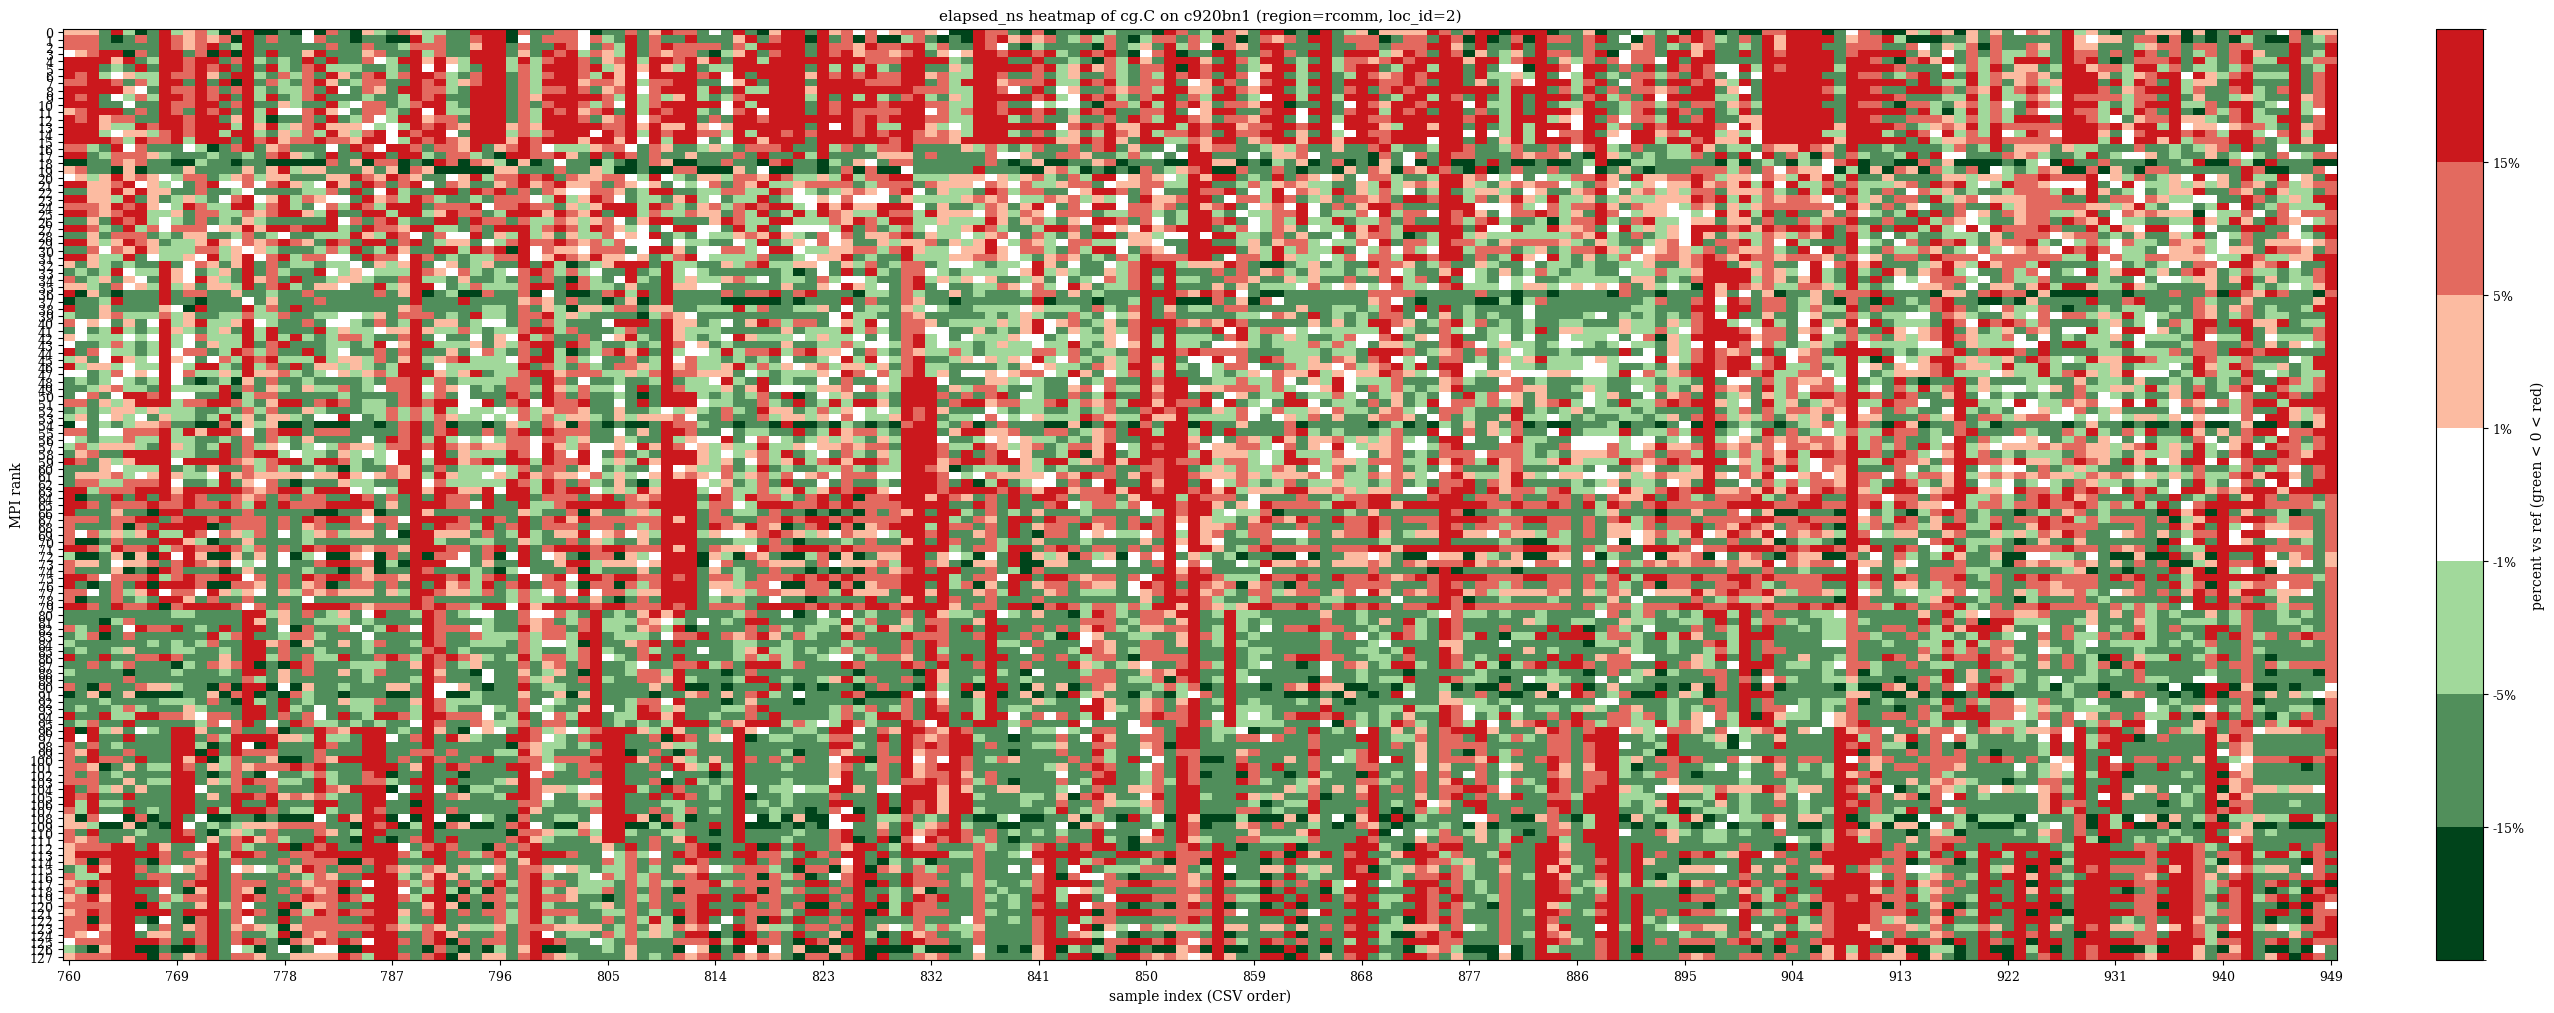

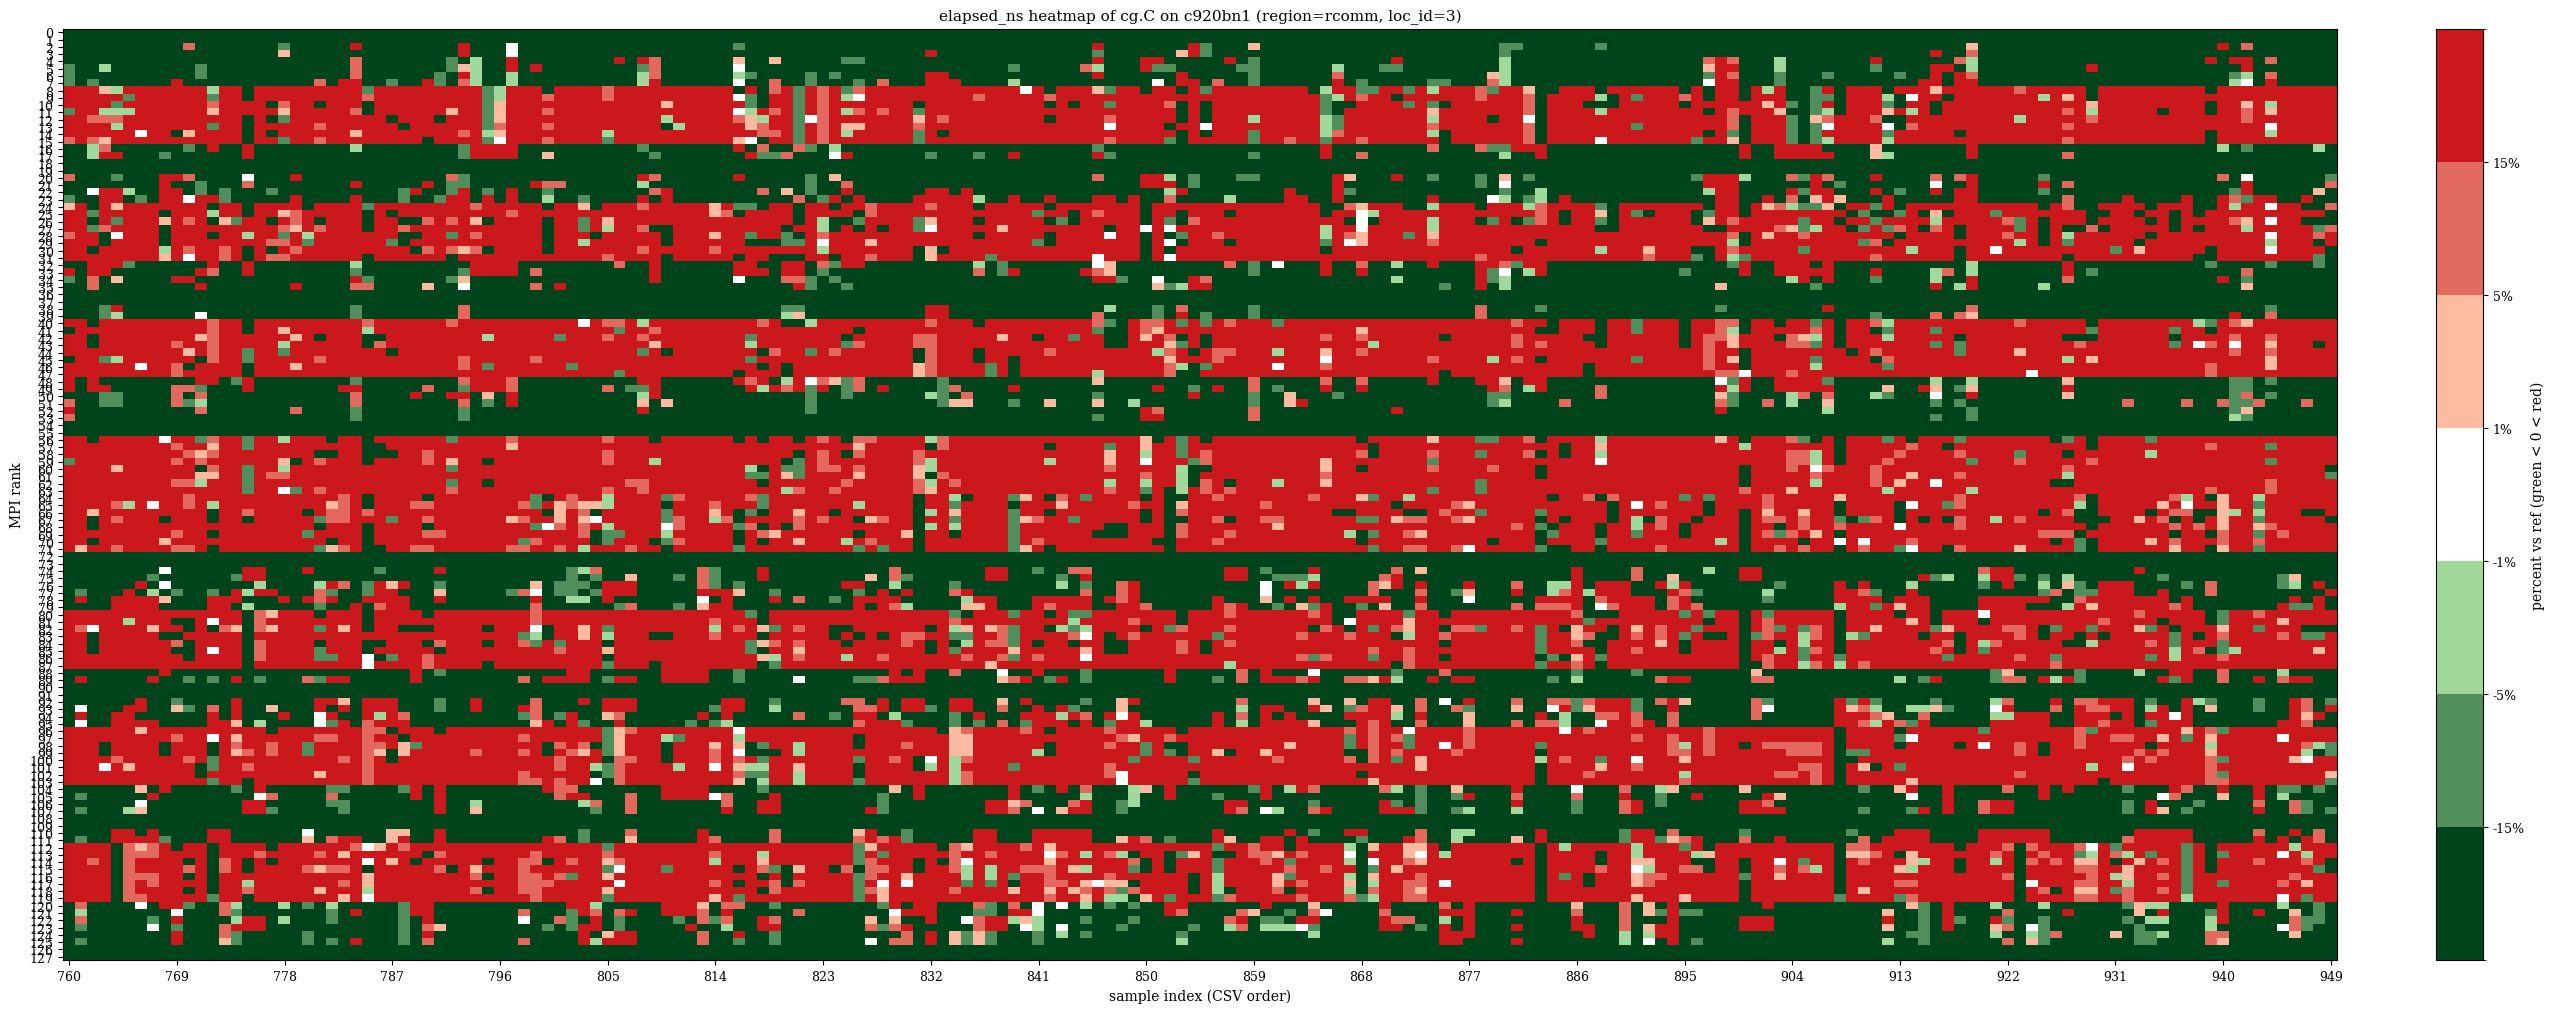

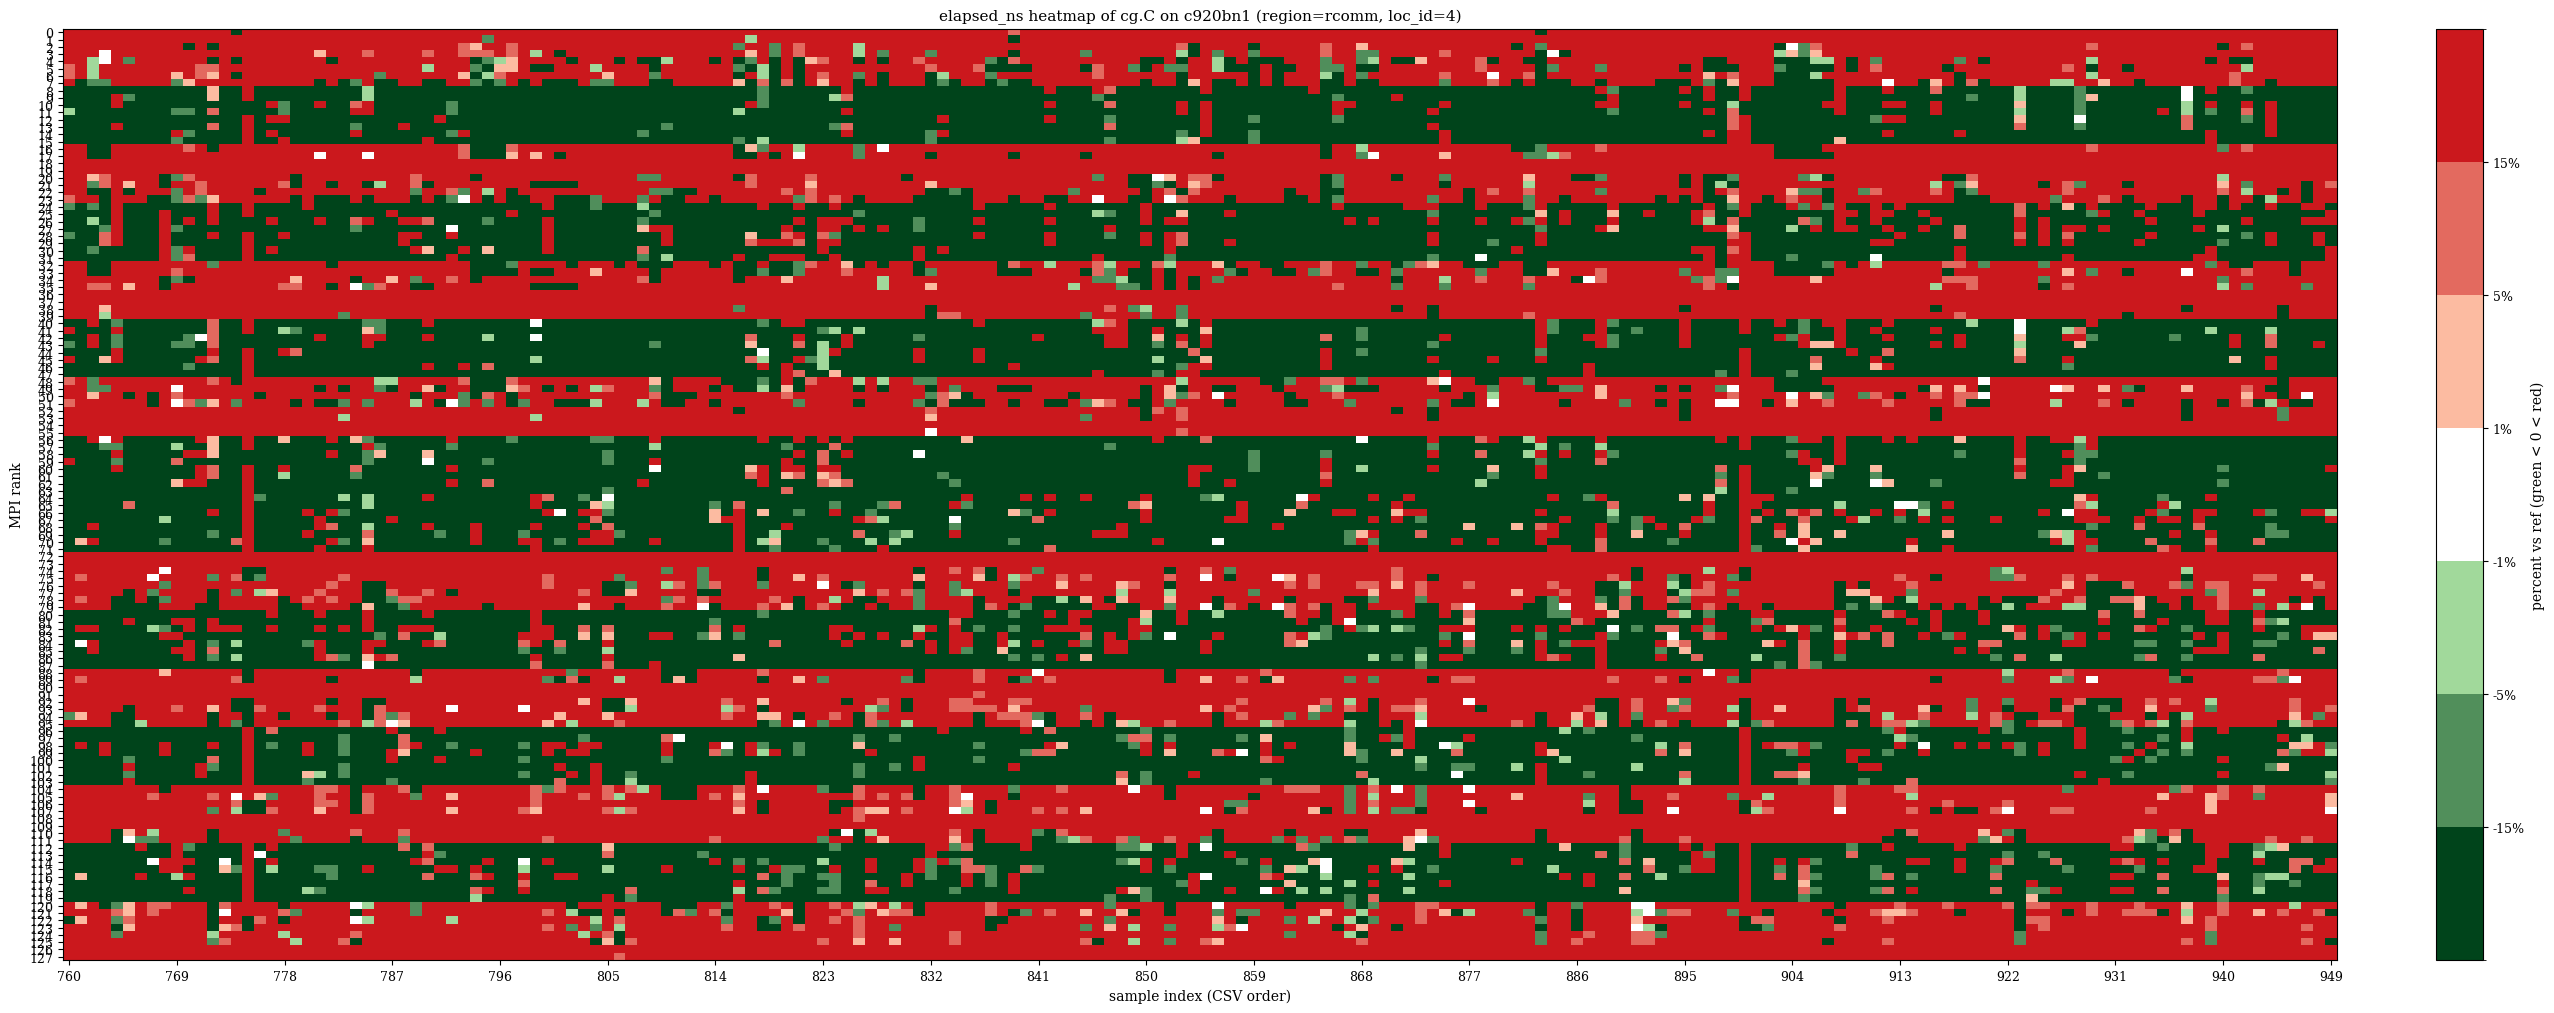

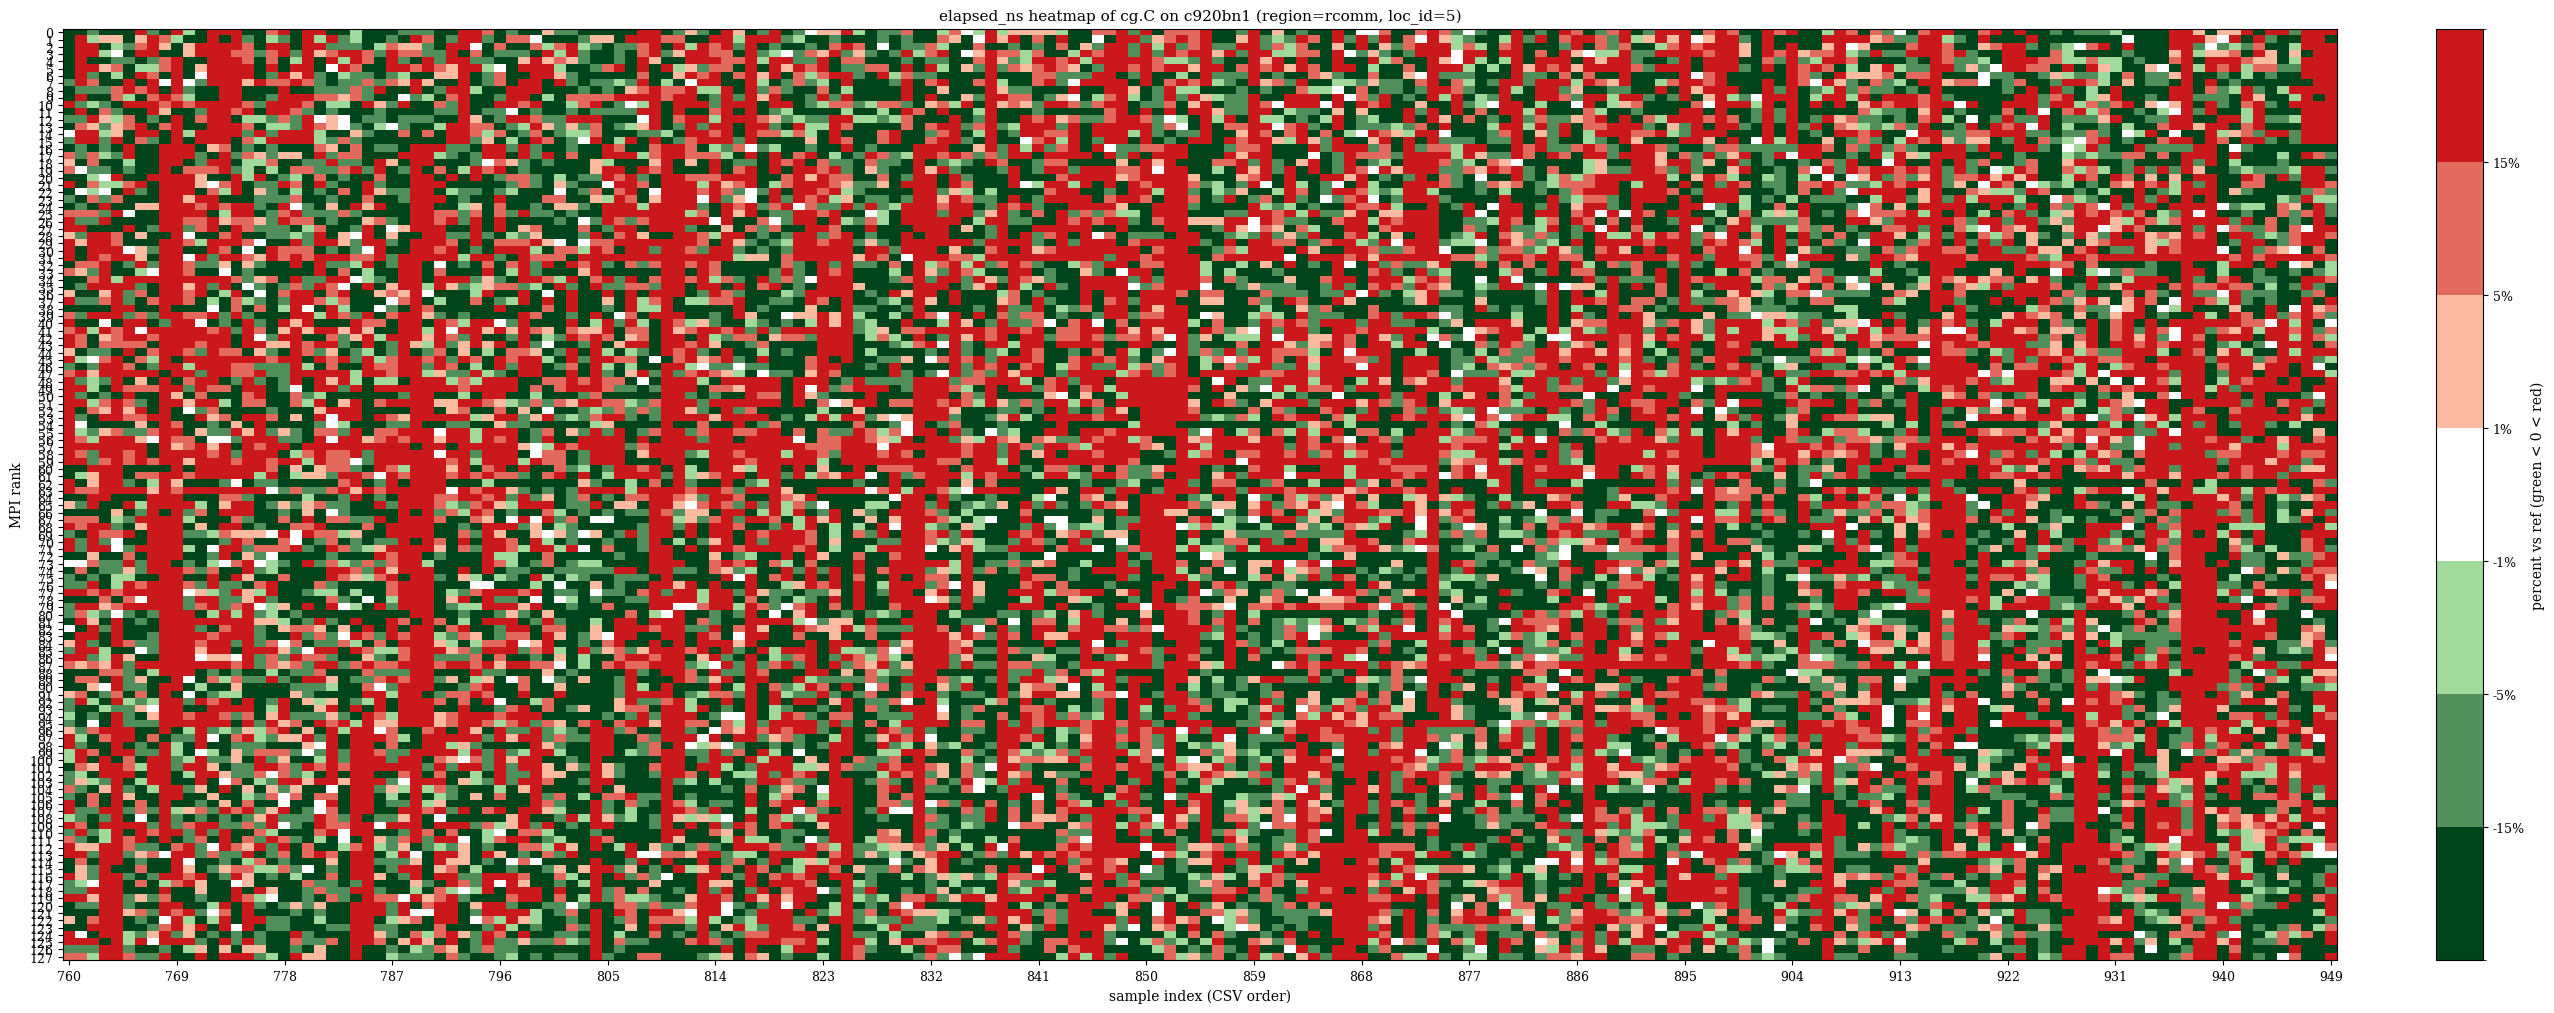

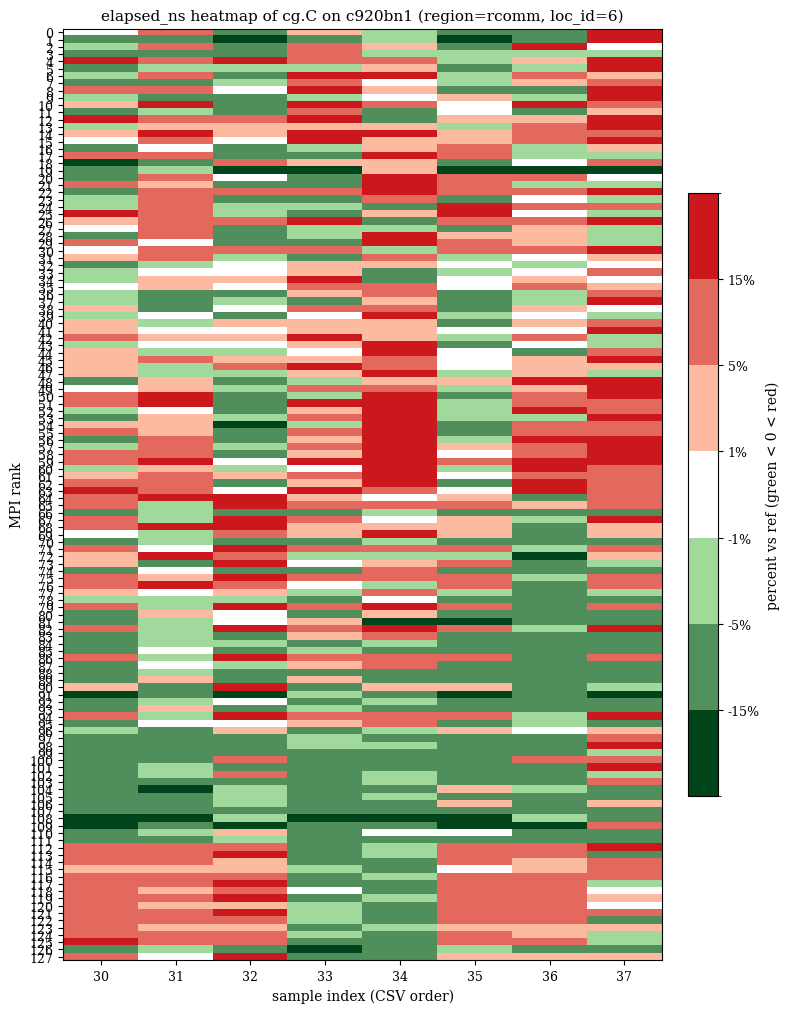

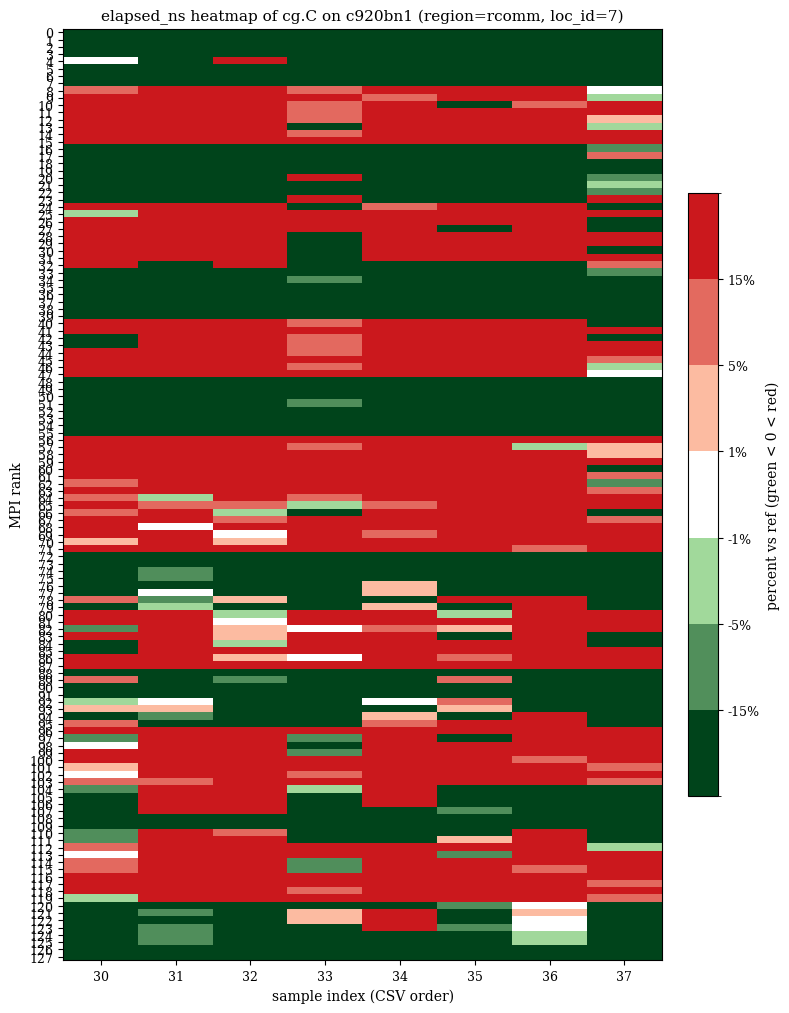

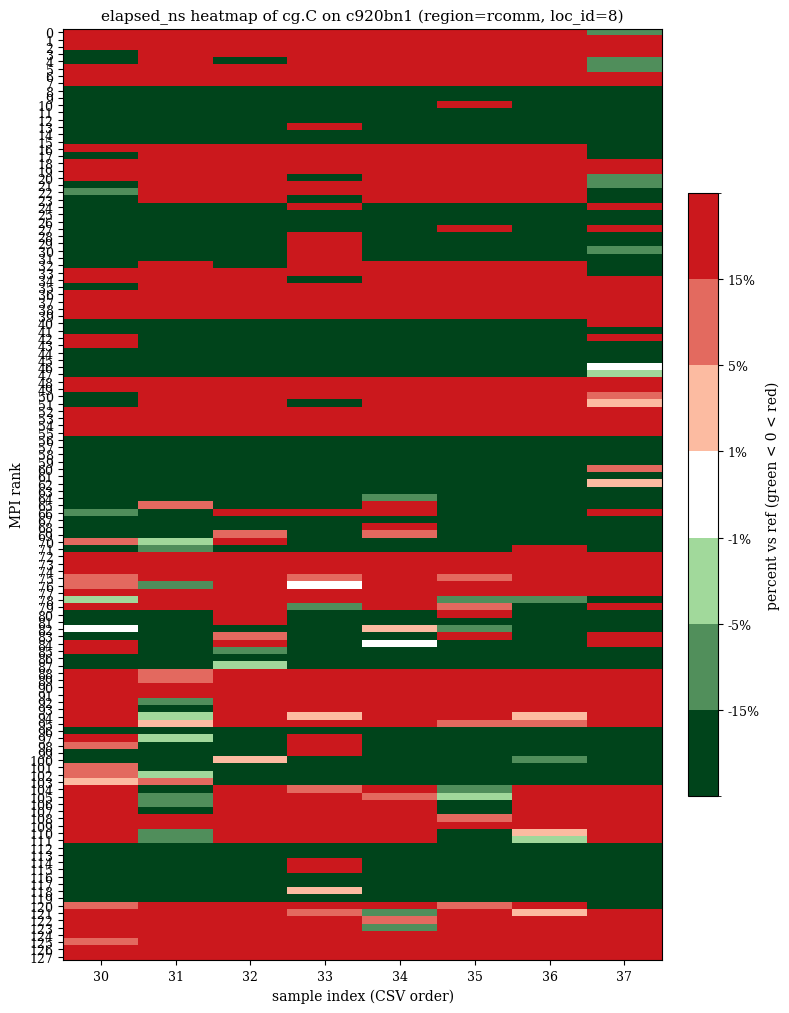

[<Figure size 800x1024 with 2 Axes>,
 <Figure size 2580x1024 with 2 Axes>,
 <Figure size 2580x1024 with 2 Axes>,
 <Figure size 2580x1024 with 2 Axes>,
 <Figure size 2580x1024 with 2 Axes>,
 <Figure size 800x1024 with 2 Axes>,
 <Figure size 800x1024 with 2 Axes>,
 <Figure size 800x1024 with 2 Axes>]

In [2]:
import importlib
import matplotlib.pyplot as plt
import tacvar_visual as tvvis
import tacvar_visual.heatmap as _tvh
import tacvar_visual.io as _tvio
importlib.reload(_tvio)
importlib.reload(_tvh)
importlib.reload(tvvis)
plt.close('all')

# Point data_root at a TacVar data_* directory from an NPB-MPI run, e.g.:
# data_root = '../suites/NPB3.4.4/NPB3.4-MPI/data_20260813T082100'
data_root = '/mnt/keylabmain/nfs/hpckey/03-Project/TacVar_NPC/suites/NPB3.4.4/NPB3.4-MPI/data_20260813T092308'
kernel_name = 'cg'
kernel_class = 'C'
hosts = ['all']
region_ids = [3]  # empty → all region_ids
loc_ids = []     # empty → all loc_ids
fom = 'elapsed_ns'
xrange = (0.4, 0.5)
ref_section_base = True
ref_key = 'median'
ref_base = 'all'
bars = [-15, -5, -1, 1, 5, 15]

figs = tvvis.draw_heatmap_npb_mpi(
    data_root,
    kernel_name,
    kernel_class,
    hosts=hosts,
    region_ids=region_ids,
    loc_ids=loc_ids,
    fom=fom,
    xrange=xrange,
    ref_section_base=ref_section_base,
    ref_key=ref_key,
    ref_base=ref_base,
    bars=bars,
)
figs
